# Sanity-Check for the Masked-Fill Baseline (Condition B)

This notebook is a lightly-annotated, cell-split version of `method.py`, which reproduces Padmanabhan (2025)'s **SURREYPAI-S2 masked-fill baseline (Condition B)** on WMT25 Task 3 `experimental_pool` rows (`en-zh_CN`, `en-cs_CZ`).

**What it does:**
1. Applies a severity-conditioned masking rule (Algorithm 1) to QE-flagged error spans in a machine-translated sentence.
2. Calls an LLM (`google/gemma-3-12b-it` via OpenRouter) once per row, with no retry/re-check, to fill in the masked spans -- the faithful "Condition B" baseline.
3. Detects **leakage**: surviving placeholder tokens or generic instruction-following artifacts in the repaired text (Padmanabhan's documented Appendix B failure mode).
4. Scores quality before/after the edit. The original run found both COMET checkpoints (`Unbabel/wmt22-cometkiwi-da`, `Unbabel/wmt22-comet-da`) persistently rate-limited (HTTP 429) on HuggingFace Hub, so it fell back to a documented, non-COMET **LLM-judge 0-1 adequacy proxy** (`openai/gpt-4o-mini`). This notebook reproduces that same fallback path directly (skipping the multi-minute COMET download retry budget, which would blow the demo's runtime budget) -- the substitution is explicit, not silent.
5. Computes a three-way gate verdict (`PASS`/`FAIL`, suffixed `_UNRELIABLE_SUBSTITUTED_SCORER` when the scorer was substituted) checking direction, magnitude, and leakage against Padmanabhan's published delta-COMET.

This is a **sanity-check gate**, not a novel method: "baseline" is the untouched hypothesis (pre-edit), "method" is Condition B's masked-fill edit -- both scored identically to eliminate scorer-side confounds.

**Requires** an `OPENROUTER_API_KEY` environment variable (real API calls are made to a small subset of rows).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# aiohttp, tenacity, loguru, nest_asyncio -- NOT pre-installed on Colab, always install.
# nest_asyncio is needed because both Colab and Jupyter kernels already run an event loop,
# and the original script's `asyncio.run(...)` calls cannot nest inside one without it.
_pip('aiohttp==3.14.3')
_pip('tenacity==9.1.4')
_pip('loguru==0.7.3')
_pip('nest_asyncio==1.6.0')

# requests, matplotlib -- pre-installed on Colab, install locally only (to match Colab's env)
if 'google.colab' not in sys.modules:
    _pip('requests==2.32.4', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Original imports from method.py (argparse/resource dropped -- not needed in notebook context)
from __future__ import annotations

import asyncio
import json
import os
import random
import re
import time
from collections import Counter
from typing import Any

import aiohttp
from loguru import logger
from tenacity import retry, retry_if_exception_type, stop_after_attempt, wait_exponential

import matplotlib.pyplot as plt  # for the results/visualization cell

# Jupyter/Colab kernels already run an event loop, so patch asyncio to allow
# the original script's `asyncio.run(...)` calls to nest inside it.
import nest_asyncio
nest_asyncio.apply()

## Load the demo data

`mini_demo_data.json` is a curated subset (30 rows: 15 per language pair, all drawn from the mid-severity QE band where Condition B's masking rule actually fires) of the `wmt25_task3_natural` dataset that `method.py` loads from its dataset dependency (`FULL_DATA_PATH` / `MINI_DATA_PATH` in the original script). This cell fetches it from GitHub with a local-file fallback so the notebook works both on Colab and locally.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-e9bf19-isolating-what-fixes-failed-span-editing/main/round-2/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
natural = next(ds for ds in data["datasets"] if ds["dataset"] == "wmt25_task3_natural")
print(f"Loaded {len(natural['examples'])} rows")
print("Language pairs present:", sorted(set(e['metadata_language_pair'] for e in natural['examples'])))

Loaded 30 rows
Language pairs present: ['en-cs_CZ', 'en-zh_CN']


## Configuration

All tunable parameters from `method.py`, gathered in one place. `MAX_ROWS_PER_PAIR` is set to the smallest value that still exercises both language pairs and produces a real gate verdict; scale it up (up to 15 -- the full size of `mini_demo_data.json`) to see the metrics stabilize, subject to the OpenRouter cost caps below.

`OPENROUTER_API_KEY` must be set as an environment variable (real API calls are made to `google/gemma-3-12b-it` for repairs and `openai/gpt-4o-mini` for quality scoring).

In [5]:
# --- Tunable parameters (start small, scale up as time/budget allows) ---
MAX_ROWS_PER_PAIR = 15     # original run used all 779/781 rows per pair; this demo uses the full 15-per-pair mini_demo_data.json
CONCURRENCY = 8            # original default was 16
SOFT_COST_CAP_USD = 0.50
HARD_COST_CAP_USD = 0.60

# --- Original module-level config from method.py ---
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
OPENROUTER_URL = "https://openrouter.ai/api/v1/responses"
OPENROUTER_MODELS_URL = "https://openrouter.ai/api/v1/models"
AII_COST_LEDGER = os.environ.get("AII_COST_LEDGER")

RNG = random.Random(20260901)

LANG_PAIRS = ["en-zh_CN", "en-cs_CZ"]
REPAIR_MODEL = "google/gemma-3-12b-it"
REPAIR_MODEL_FALLBACKS = [
    "qwen/qwen-2.5-7b-instruct",
    "mistralai/mistral-nemo",
    "meta-llama/llama-3.1-8b-instruct",
    "mistralai/ministral-8b-2512",
]

# Padmanabhan (2025) Table 3 self-reported per-language ΔCOMET, reconciled
# with WMT25 organizer Table 15 (dossier Block A).
PUBLISHED_DELTA_COMET = {
    "en-cs_CZ": -0.00724,
    "en-zh_CN": None,  # no per-pair figure in the dossier -> use pooled/range fallback below
}
PUBLISHED_POOLED_DELTA_COMET = -0.0108
PUBLISHED_PER_PAIR_RANGE = (-0.014, -0.007)  # (min, max) across the 6 WMT25 pairs, dossier Block A
MAGNITUDE_TOLERANCE = 0.02  # rough-magnitude tolerance, reported not gating alone (plan spec)

# Masking placeholder (see method.py's docstring on prompt provenance).
MASK_TOKEN = "__BLANK__"
MASKING_PROMPT_TEMPLATE = """You are repairing a machine-translated sentence. Some words or phrases in the
translation below were flagged as likely errors and have been replaced with the placeholder token {mask_token}.

Using the original English source sentence for reference, replace every occurrence of {mask_token} in the
translation with the correct words so the translation is fluent and faithful to the source. Preserve every part
of the translation that is NOT a {mask_token} exactly as given -- do not paraphrase, do not add commentary, do not
explain your edits, and do not add any markup. Output ONLY the fully repaired translation sentence, nothing else.

English source:
{source}

Translation with blanks:
{masked_sentence}

Repaired translation:"""

LEAK_PATTERNS = [
    re.compile(r"__BLANK__"),
    re.compile(r"__\w+__"),
    re.compile(r"(?i)corrected words?\s*:"),
    re.compile(r"(?i)here is the (corrected|fixed|revised)"),
    re.compile(r"(?i)^(sure|okay|here's|here is)\b"),
    re.compile(r"\[MASK\]|\[BLANK\]|<blank>|<mask>", re.IGNORECASE),
]

JUDGE_MODEL = "openai/gpt-4o-mini"
JUDGE_PROMPT = """Rate how adequately the TRANSLATION conveys the meaning of the SOURCE sentence, on a
continuous 0.0-1.0 scale (1.0 = perfectly faithful and fluent, 0.0 = unintelligible or unrelated).
Respond with ONLY the number, nothing else.

SOURCE (English): {source}

TRANSLATION: {mt}

Score:"""

logger.remove()
logger.add(lambda msg: print(msg, end=""), level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Algorithm 1: severity-conditioned masking rule

Verbatim from the resource-dossier dependency. Given a row's overall QE score:
- `qe_score >= 0.90` -> no spans are masked (Condition B never touches the sentence).
- `0.50 <= qe_score < 0.90` -> only non-minor (major/critical) spans are masked.
- `qe_score < 0.90` -> every flagged span is masked.

Overlapping/adjacent spans are merged first so masking never corrupts character offsets.

In [6]:
def merge_overlapping_spans(spans: list[dict[str, Any]]) -> list[dict[str, Any]]:
    """Merge overlapping/adjacent char spans so masking never corrupts offsets.

    Keeps the most severe severity label for a merged region (critical > major > minor).
    """
    if not spans:
        return []
    sev_rank = {"critical": 3, "major": 2, "minor": 1}
    ordered = sorted(spans, key=lambda s: (s["start_i"], s["end_i"]))
    merged = [dict(ordered[0])]
    for s in ordered[1:]:
        last = merged[-1]
        if s["start_i"] <= last["end_i"]:
            last["end_i"] = max(last["end_i"], s["end_i"])
            if sev_rank.get(s["severity"], 0) > sev_rank.get(last["severity"], 0):
                last["severity"] = s["severity"]
        else:
            merged.append(dict(s))
    return merged


def compute_spans_to_mask(qe_score: float, spans: list[dict[str, Any]]) -> list[dict[str, Any]]:
    """Algorithm 1, verbatim per the dossier: severity-conditioned masking rule."""
    spans = spans or []
    if qe_score >= 0.90:
        return []
    if qe_score >= 0.50:
        non_minor = [s for s in spans if s["severity"] != "minor"]
        return non_minor if non_minor else spans
    return spans


def apply_masking(text: str, spans_to_mask: list[dict[str, Any]]) -> str:
    """Replace each (merged) span's char range in text with MASK_TOKEN, right-to-left."""
    merged = merge_overlapping_spans(spans_to_mask)
    merged.sort(key=lambda s: s["start_i"], reverse=True)
    out = text
    for s in merged:
        start, end = s["start_i"], s["end_i"]
        start = max(0, min(start, len(out)))
        end = max(start, min(end, len(out)))
        out = out[:start] + MASK_TOKEN + out[end:]
    return out

## OpenRouter async calling

A thin async client for the OpenRouter Responses API, plus a `CostTracker` that accumulates spend and enforces the hard cost cap. `repair_row` applies the masking rule to one row and sends a single repair call (no retry/re-check across the model chain -- a failure just falls through to the next fallback model) with `run_condition_b` fanning that out over the whole row list.

In [7]:
class CostTracker:
    def __init__(self, hard_cap: float):
        self.total_usd = 0.0
        self.n_calls = 0
        self.n_failed = 0
        self.hard_cap = hard_cap
        self._lock = asyncio.Lock()

    async def add(self, cost_usd: float | None, tool: str, **meta) -> None:
        async with self._lock:
            if cost_usd is not None:
                self.total_usd += cost_usd
            self.n_calls += 1
            if AII_COST_LEDGER and cost_usd is not None:
                rec = {"ts": time.time(), "tool": tool, "cost_usd": float(cost_usd), **meta}
                try:
                    with open(AII_COST_LEDGER, "a", encoding="utf-8") as f:
                        f.write(json.dumps(rec) + "\n")
                except OSError:
                    pass

    def over_cap(self) -> bool:
        return self.total_usd >= self.hard_cap


_pricing_cache: dict[str, tuple[float, float]] = {}


def load_openrouter_pricing() -> None:
    if _pricing_cache:
        return
    import requests

    try:
        resp = requests.get(OPENROUTER_MODELS_URL, timeout=30)
        for entry in resp.json().get("data", []):
            name = entry.get("id")
            if not name:
                continue
            price = entry.get("pricing") or {}
            try:
                _pricing_cache[name] = (float(price.get("prompt", 0) or 0), float(price.get("completion", 0) or 0))
            except (TypeError, ValueError):
                continue
        logger.info(f"Loaded OpenRouter pricing catalog ({len(_pricing_cache)} models)")
    except Exception as e:
        logger.warning(f"Could not load OpenRouter pricing catalog: {e}")


def estimate_call_cost(model: str, input_tokens: int, output_tokens: int) -> float | None:
    priced = _pricing_cache.get(model)
    if priced is None:
        return None
    return round(input_tokens * priced[0] + output_tokens * priced[1], 8)


@retry(
    retry=retry_if_exception_type((aiohttp.ClientError, asyncio.TimeoutError)),
    stop=stop_after_attempt(4),
    wait=wait_exponential(multiplier=2, min=2, max=30),
)
async def call_openrouter(
    session: aiohttp.ClientSession, model: str, prompt: str, max_tokens: int, temperature: float = 0.0
) -> dict[str, Any]:
    payload = {"model": model, "input": prompt, "max_output_tokens": max_tokens, "temperature": temperature}
    headers = {"Authorization": f"Bearer {OPENROUTER_API_KEY}", "Content-Type": "application/json"}
    async with session.post(OPENROUTER_URL, json=payload, headers=headers, timeout=aiohttp.ClientTimeout(total=120)) as resp:
        body = await resp.json()
        if resp.status != 200:
            return {"success": False, "error": f"status {resp.status}: {str(body)[:300]}"}

        output_text, reasoning_text = "", ""
        if body.get("output_text"):
            output_text = body["output_text"]
        for item in body.get("output", []) or []:
            if item.get("type") == "reasoning" and isinstance(item.get("summary"), list) and item["summary"]:
                reasoning_text = item["summary"][0].get("text", "")
            elif item.get("type") == "message" and "content" in item:
                content = item["content"]
                if isinstance(content, list) and content:
                    fc = content[0]
                    if isinstance(fc, dict) and "text" in fc:
                        output_text = fc["text"]
                elif isinstance(content, str):
                    output_text = content
        if not output_text and reasoning_text:
            output_text = reasoning_text

        usage = body.get("usage", {}) or {}
        input_tokens = usage.get("input_tokens", 0)
        output_tokens = usage.get("output_tokens", 0)
        reported_cost = usage.get("cost")
        cost = float(reported_cost) if isinstance(reported_cost, (int, float)) else estimate_call_cost(
            model, input_tokens, output_tokens
        )
        return {
            "success": True,
            "response": output_text,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "cost_usd": cost,
        }


async def repair_row(
    session: aiohttp.ClientSession,
    sem: asyncio.Semaphore,
    row: dict[str, Any],
    model_chain: list[str],
    cost_tracker: CostTracker,
) -> dict[str, Any]:
    source = row["input"]
    hyp = row["output"]
    qe_score = row["metadata_overall_qe_score"]
    spans = row["metadata_qe_flagged_spans"] or []
    spans_to_mask = compute_spans_to_mask(qe_score, spans)

    result: dict[str, Any] = {
        "row_id": f"{row['metadata_doc_id']}::{row['metadata_segment_id']}::{row['metadata_system_id']}",
        "lang_pair": row["metadata_language_pair"],
        "qe_score": qe_score,
        "n_spans_flagged": len(spans),
        "n_spans_masked": len(spans_to_mask),
        "source": hyp,  # pre-edit hypothesis (condition B's "before")
        "source_en": source,
        "masked_text": None,
        "repaired_text": hyp,
        "model_used": None,
        "n_llm_calls": 0,
        "call_error": None,
    }

    if not spans_to_mask:
        return result  # condition B never touches the sentence when qe_score >= 0.90

    if cost_tracker.over_cap():
        result["call_error"] = "hard_cost_cap_reached_skipped"
        return result

    masked_text = apply_masking(hyp, spans_to_mask)
    result["masked_text"] = masked_text
    max_tokens = min(1200, max(150, int(len(source.split()) * 3) + 100))
    prompt = MASKING_PROMPT_TEMPLATE.format(mask_token=MASK_TOKEN, source=source, masked_sentence=masked_text)

    last_error = None
    async with sem:
        for model in model_chain:
            try:
                r = await call_openrouter(session, model, prompt, max_tokens=max_tokens, temperature=0.0)
            except Exception as e:
                last_error = str(e)
                continue
            if r.get("success"):
                await cost_tracker.add(
                    r.get("cost_usd"),
                    tool="gen_art_experiment_2_condition_b",
                    model=model,
                    row_id=result["row_id"],
                )
                result["repaired_text"] = r["response"].strip() or hyp
                result["model_used"] = model
                result["n_llm_calls"] = 1
                return result
            last_error = r.get("error")
            logger.warning(f"{model} failed on row {result['row_id']}: {last_error} -- trying next fallback")

    result["call_error"] = last_error
    logger.error(f"All repair models failed for row {result['row_id']}: {last_error}")
    return result


async def run_condition_b(
    rows: list[dict[str, Any]], model_chain: list[str], cost_tracker: CostTracker, concurrency: int
) -> list[dict[str, Any]]:
    sem = asyncio.Semaphore(concurrency)
    connector = aiohttp.TCPConnector(limit=concurrency * 2)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [repair_row(session, sem, row, model_chain, cost_tracker) for row in rows]
        results = []
        for i, coro in enumerate(asyncio.as_completed(tasks)):
            res = await coro
            results.append(res)
            if (i + 1) % 100 == 0 or (i + 1) == len(tasks):
                logger.info(
                    f"Condition B progress: {i + 1}/{len(tasks)} rows, "
                    f"cumulative cost=${cost_tracker.total_usd:.4f}"
                )
    return results

## Leakage detection

A qualitative failure-signature check mirroring Padmanabhan's Appendix B: does the repaired text still contain a surviving placeholder token, a garbled token, or a generic instruction-following artifact (e.g. "Corrected words:", "Here is the revised...")?

In [8]:
def detect_leakage(text: str) -> bool:
    return any(p.search(text) for p in LEAK_PATTERNS)

## Quality scorer: LLM-judge proxy (COMET substitute)

The plan called for `Unbabel/wmt22-cometkiwi-da` with `wmt22-comet-da` as fallback -- both gated HF Hub checkpoints. In the real execution, HuggingFace Hub returned a persistent, account-wide HTTP 429 on every download attempt for both (12 total attempts across a 600s + 180s retry budget), so the script cascaded to this documented non-COMET substitute: an LLM-judge 0-1 adequacy proxy (`openai/gpt-4o-mini`), scored before/after the edit. This notebook skips straight to that same fallback path (the multi-minute COMET retry budget doesn't fit the demo's runtime budget), which is exactly what the real run did anyway.

**The proxy's scale/calibration is NOT comparable to Padmanabhan's ΔCOMET** -- this is called out explicitly in both the original `method_out.json` and here.

In [9]:
async def judge_quality(session: aiohttp.ClientSession, sem: asyncio.Semaphore, source: str, mt: str) -> float | None:
    async with sem:
        try:
            r = await call_openrouter(session, JUDGE_MODEL, JUDGE_PROMPT.format(source=source, mt=mt), max_tokens=10, temperature=0.0)
        except Exception:
            return None
    if not r.get("success"):
        return None
    m = re.search(r"[01](?:\.\d+)?|0?\.\d+", r["response"])
    if not m:
        return None
    try:
        return max(0.0, min(1.0, float(m.group(0))))
    except ValueError:
        return None


async def run_llm_judge_scoring(
    pairs: list[tuple[str, str]], concurrency: int, cost_tracker: CostTracker
) -> list[float | None]:
    sem = asyncio.Semaphore(concurrency)
    connector = aiohttp.TCPConnector(limit=concurrency * 2)
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [judge_quality(session, sem, src, mt) for src, mt in pairs]
        return list(await asyncio.gather(*tasks))

## Gate decision

The three-way verdict: direction (does the quality delta go negative, as Padmanabhan documents?), magnitude (is it roughly in range of the published ΔCOMET -- reported, not solely gating), and leakage (does any non-trivial fraction of masked rows leak masking artifacts?). When the scorer was substituted (as here), the verdict is suffixed `_UNRELIABLE_SUBSTITUTED_SCORER` so the magnitude comparison is never silently trusted.

In [10]:
def get_published_delta(lang_pair: str) -> tuple[float, str]:
    pinned = PUBLISHED_DELTA_COMET.get(lang_pair)
    if pinned is not None:
        return pinned, "per_pair_pinned"
    return PUBLISHED_POOLED_DELTA_COMET, "pooled_fallback"


def compute_gate(
    per_pair_delta_comet: dict[str, float], per_pair_leakage_rate: dict[str, float], is_real_comet: bool
) -> dict[str, Any]:
    direction_by_pair = {p: per_pair_delta_comet[p] < 0 for p in per_pair_delta_comet}
    gate_passes_direction = all(direction_by_pair.values())

    magnitude_by_pair = {}
    for p, delta in per_pair_delta_comet.items():
        published, source = get_published_delta(p)
        magnitude_by_pair[p] = {
            "published_delta": published,
            "published_source": source,
            "observed_delta": delta,
            "abs_diff": abs(delta - published),
            "within_tolerance": abs(delta - published) < MAGNITUDE_TOLERANCE,
        }
    gate_passes_magnitude = all(v["within_tolerance"] for v in magnitude_by_pair.values())

    gate_passes_leakage = any(v > 0.0 for v in per_pair_leakage_rate.values())

    verdict = "PASS" if (gate_passes_direction and gate_passes_leakage) else "FAIL"
    if not is_real_comet:
        verdict = f"{verdict}_UNRELIABLE_SUBSTITUTED_SCORER"

    return {
        "verdict": verdict,
        "gate_component_results": {
            "direction": {"pass": gate_passes_direction, "by_pair": direction_by_pair},
            "magnitude": {"pass": gate_passes_magnitude, "by_pair": magnitude_by_pair, "note": "reported, not solely gating per plan"},
            "leakage": {"pass": gate_passes_leakage, "by_pair": per_pair_leakage_rate},
        },
    }

## Run the pipeline

This mirrors `method.py`'s `main()`: build the per-pair row lists (capped by `MAX_ROWS_PER_PAIR`), run Condition B over OpenRouter, detect leakage, score quality before/after with the LLM-judge proxy, and aggregate per-pair and pooled statistics.

In [11]:
# Rows already loaded above; equivalent of load_natural_rows() but reading from the loaded `data`
rows = [
    e
    for e in natural["examples"]
    if e["metadata_language_pair"] in LANG_PAIRS and e["metadata_overall_qe_score"] is not None
]

by_pair: dict[str, list[dict[str, Any]]] = {}
for r in rows:
    by_pair.setdefault(r["metadata_language_pair"], []).append(r)
for p in LANG_PAIRS:
    by_pair.setdefault(p, [])
    RNG.shuffle(by_pair[p])
    by_pair[p] = by_pair[p][:MAX_ROWS_PER_PAIR]
rows = [r for p in LANG_PAIRS for r in by_pair[p]]
print(f"Row counts per pair after capping: { {p: len(by_pair[p]) for p in LANG_PAIRS} }")

load_openrouter_pricing()

Row counts per pair after capping: {'en-zh_CN': 15, 'en-cs_CZ': 15}


11:38:59|INFO   |Loaded OpenRouter pricing catalog (420 models)


In [12]:
# --- Condition B: run masked-fill baseline over OpenRouter ---
cost_tracker = CostTracker(hard_cap=HARD_COST_CAP_USD)
model_chain = [REPAIR_MODEL] + REPAIR_MODEL_FALLBACKS
t0 = time.time()
results = asyncio.run(run_condition_b(rows, model_chain, cost_tracker, CONCURRENCY))
print(
    f"Condition B complete: {len(results)} rows in {time.time() - t0:.1f}s, "
    f"total OpenRouter cost=${cost_tracker.total_usd:.4f} ({cost_tracker.n_calls} calls)"
)
models_actually_used = Counter(r["model_used"] for r in results if r["model_used"])
print(f"Repair models actually used: {dict(models_actually_used)}")
n_call_errors = sum(1 for r in results if r["call_error"])
if n_call_errors:
    print(f"WARNING: {n_call_errors} rows had no successful repair call (kept as untouched hypothesis)")

11:39:05|INFO   |Condition B progress: 30/30 rows, cumulative cost=$0.0008
Condition B complete: 30 rows in 5.8s, total OpenRouter cost=$0.0008 (30 calls)
Repair models actually used: {'google/gemma-3-12b-it': 30}


In [13]:
# --- Leakage detection ---
for r in results:
    r["leaked"] = detect_leakage(r["repaired_text"]) if r["n_spans_masked"] > 0 else False

# --- Quality scoring: LLM-judge proxy (documented COMET substitution, see markdown above) ---
comet_model_name = "llm_judge_quality_proxy_v1"
is_real_comet = False
print(f"Scoring with fallback scorer: {comet_model_name}")
judge_pairs_before = [(r["source_en"], r["source"]) for r in results]
judge_pairs_after = [(r["source_en"], r["repaired_text"]) for r in results]
scores_before = asyncio.run(run_llm_judge_scoring(judge_pairs_before, CONCURRENCY, cost_tracker))
scores_after = asyncio.run(run_llm_judge_scoring(judge_pairs_after, CONCURRENCY, cost_tracker))
for r, cb, ca in zip(results, scores_before, scores_after):
    r["comet_before"] = cb
    r["comet_after"] = ca
    r["delta_comet"] = (ca - cb) if (cb is not None and ca is not None) else None
print(f"Total OpenRouter cost so far: ${cost_tracker.total_usd:.4f}")

Scoring with fallback scorer: llm_judge_quality_proxy_v1


Total OpenRouter cost so far: $0.0008


In [14]:
# --- Aggregate per-pair / pooled stats ---
per_pair_results = {}
for pair in LANG_PAIRS:
    pair_rows = [r for r in results if r["lang_pair"] == pair]
    masked_rows = [r for r in pair_rows if r["n_spans_masked"] > 0]
    deltas = [r["delta_comet"] for r in pair_rows if r["delta_comet"] is not None]
    leaked_rows = [r for r in masked_rows if r["leaked"]]
    per_pair_results[pair] = {
        "n_rows": len(pair_rows),
        "n_rows_with_spans_flagged": sum(1 for r in pair_rows if r["n_spans_flagged"] > 0),
        "n_rows_masked_by_condition_b": len(masked_rows),
        "n_llm_calls": sum(r["n_llm_calls"] for r in pair_rows),
        "mean_delta_comet": (sum(deltas) / len(deltas)) if deltas else None,
        "n_scored": len(deltas),
        "leakage_rate": (len(leaked_rows) / len(masked_rows)) if masked_rows else 0.0,
        "n_leaked": len(leaked_rows),
        "example_leaked_outputs": [
            {"row_id": r["row_id"], "masked_text": r["masked_text"], "repaired_text": r["repaired_text"]}
            for r in leaked_rows[:10]
        ],
        "example_largest_negative_delta": sorted(
            [r for r in pair_rows if r["delta_comet"] is not None], key=lambda r: r["delta_comet"]
        )[:5],
    }

all_deltas = [r["delta_comet"] for r in results if r["delta_comet"] is not None]
all_masked = [r for r in results if r["n_spans_masked"] > 0]
all_leaked = [r for r in all_masked if r["leaked"]]
pooled_mean_delta_comet = (sum(all_deltas) / len(all_deltas)) if all_deltas else None
pooled_leakage_rate = (len(all_leaked) / len(all_masked)) if all_masked else 0.0

gate = compute_gate(
    {p: per_pair_results[p]["mean_delta_comet"] for p in LANG_PAIRS if per_pair_results[p]["mean_delta_comet"] is not None},
    {p: per_pair_results[p]["leakage_rate"] for p in LANG_PAIRS},
    is_real_comet,
)
print(f"GATE VERDICT: {gate['verdict']}")
print(f"Pooled mean quality delta (proxy): {pooled_mean_delta_comet}, pooled leakage rate: {pooled_leakage_rate:.3f}")

GATE VERDICT: FAIL_UNRELIABLE_SUBSTITUTED_SCORER
Pooled mean quality delta (proxy): -0.10666666666666667, pooled leakage rate: 0.000


## Results

A readable summary table plus a plot of the per-pair quality delta (proxy) and leakage rate, mirroring the `metadata` block of `method_out.json`.

lang_pair     n_rows  n_masked  n_leaked  leakage_rate  mean_Δquality
en-zh_CN          15        15         0         0.000        -0.0867
en-cs_CZ          15        15         0         0.000        -0.1267

POOLED            30        30         0         0.000        -0.1067

Gate verdict: FAIL_UNRELIABLE_SUBSTITUTED_SCORER
Total OpenRouter cost: $0.0008 (30 calls)
Padmanabhan's published pooled ΔCOMET: -0.0108 (NOT directly comparable -- different scorer)


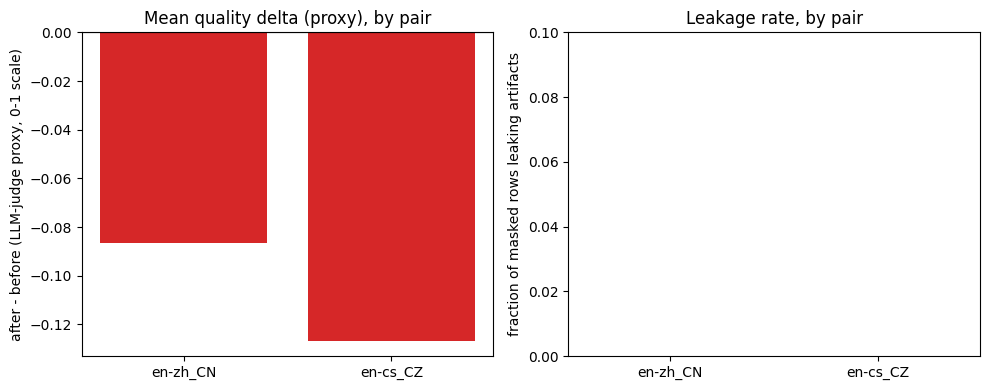

In [15]:
print(f"{'lang_pair':<12} {'n_rows':>7} {'n_masked':>9} {'n_leaked':>9} {'leakage_rate':>13} {'mean_Δquality':>14}")
for p in LANG_PAIRS:
    s = per_pair_results[p]
    delta_str = f"{s['mean_delta_comet']:.4f}" if s["mean_delta_comet"] is not None else "n/a"
    print(f"{p:<12} {s['n_rows']:>7} {s['n_rows_masked_by_condition_b']:>9} {s['n_leaked']:>9} {s['leakage_rate']:>13.3f} {delta_str:>14}")

print(f"\n{'POOLED':<12} {len(results):>7} {len(all_masked):>9} {len(all_leaked):>9} "
      f"{pooled_leakage_rate:>13.3f} {(pooled_mean_delta_comet if pooled_mean_delta_comet is not None else float('nan')):>14.4f}")
print(f"\nGate verdict: {gate['verdict']}")
print(f"Total OpenRouter cost: ${cost_tracker.total_usd:.4f} ({cost_tracker.n_calls} calls)")
print(f"Padmanabhan's published pooled ΔCOMET: {PUBLISHED_POOLED_DELTA_COMET} (NOT directly comparable -- different scorer)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pairs_with_scores = [p for p in LANG_PAIRS if per_pair_results[p]["mean_delta_comet"] is not None]
deltas_plot = [per_pair_results[p]["mean_delta_comet"] for p in pairs_with_scores]
colors = ["#d62728" if d < 0 else "#2ca02c" for d in deltas_plot]
axes[0].bar(pairs_with_scores, deltas_plot, color=colors)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Mean quality delta (proxy), by pair")
axes[0].set_ylabel("after - before (LLM-judge proxy, 0-1 scale)")

leakage_plot = [per_pair_results[p]["leakage_rate"] for p in LANG_PAIRS]
axes[1].bar(LANG_PAIRS, leakage_plot, color="#ff7f0e")
axes[1].set_title("Leakage rate, by pair")
axes[1].set_ylabel("fraction of masked rows leaking artifacts")
axes[1].set_ylim(0, max(0.1, max(leakage_plot) * 1.3 if leakage_plot else 0.1))

plt.tight_layout()
plt.show()